# Import Libaries

In [1]:
import kagglehub
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load Data

In [2]:
path = kagglehub.dataset_download("abhishekmishra08/loan-approval-datasets")
print("Path to dataset files:", path)

Path to dataset files: /home/leanna/.cache/kagglehub/datasets/abhishekmishra08/loan-approval-datasets/versions/1


In [3]:
print(os.listdir(path))

['loan_data.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "loan_data.csv"))

# Data Cleaning / Preprocessing

In [5]:
df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  str    
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  str    
 6   Approval           24000 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 1.3 MB


In [7]:
df.describe()

,Income,Credit_Score,Loan_Amount,DTI_Ratio
count,24000.000000,24000.000000,24000.000000,24000.000000
mean,110377.552708,575.720333,44356.154833,34.719167
std,51729.677627,159.227621,34666.604785,32.322471
min,20001.000000,300.000000,1005.000000,2.530000
25%,65635.750000,437.000000,16212.000000,14.507500
50%,110464.000000,575.000000,35207.000000,24.860000
75%,155187.000000,715.000000,65622.750000,41.840000
max,200000.000000,850.000000,158834.000000,246.330000


In [8]:
df.isnull().sum()

Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64

No missing values.
Numeratic statistics look reasonable
Only a couple of columns need preprocessing.

df describe shows that:
- income is between 20k-200k 
- credit score between 300 and 850
- loan amount in a wide range
- DTI ratio (debt to income) up to 246 - a bit high but still usable

In [9]:
# Dropping text column due to data being too advanced for the decision tree model.
df = df.drop("Text", axis=1)

In [10]:
# Check employment status types
df["Employment_Status"].unique()

<StringArray>
['employed', 'unemployed']
Length: 2, dtype: str

In [11]:
# Map employment statuses into integer values.
df["Employment_Status"] = df["Employment_Status"].map({"unemployed": 0, "employed": 1});
df["Employment_Status"] = df["Employment_Status"].astype(int)

In [12]:
df["Employment_Status"].unique()

array([1, 0])

In [13]:
df["Approval"] = df["Approval"].map({"Rejected": 0, "Approved": 1})
df["Approval"] = df["Approval"].astype(int)

In [14]:
df.dtypes

Income                 int64
Credit_Score           int64
Loan_Amount            int64
DTI_Ratio            float64
Employment_Status      int64
Approval               int64
dtype: object

In [15]:
df["Approval"].unique()

array([0, 1])

In [16]:
print(df[["Employment_Status", "Approval"]].isnull().sum())

Employment_Status    0
Approval             0
dtype: int64


In [17]:
X = df.drop("Approval", axis=1)
y = df["Approval"]

# Train/Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Test train split: splits dataset into two parts:
X_train and y_train: the data models learns from
X_test and y_test: the data used to check how well it performs on unseen data.
With a test_size of 0.2, which means 80 % rows goes to training and 20 % goes to testing.
The data has 24000 rows, which means 19200 to training, 4800 to testing.
The random state seed is set to 42, so that the split is repeatable.

# Train Decision Tree

In [19]:
# 1. Create model
tree_model = DecisionTreeClassifier(random_state=42, max_depth=4)

# 2. Train model 
tree_model.fit(X_train, y_train)

# 3. Predict
y_pred = tree_model.predict(X_test)

# Evaluate Model

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.960625

Confusion Matrix:
[[3905  142]
 [  47  706]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      4047
           1       0.83      0.94      0.88       753

    accuracy                           0.96      4800
   macro avg       0.91      0.95      0.93      4800
weighted avg       0.96      0.96      0.96      4800



# Visualise Tree

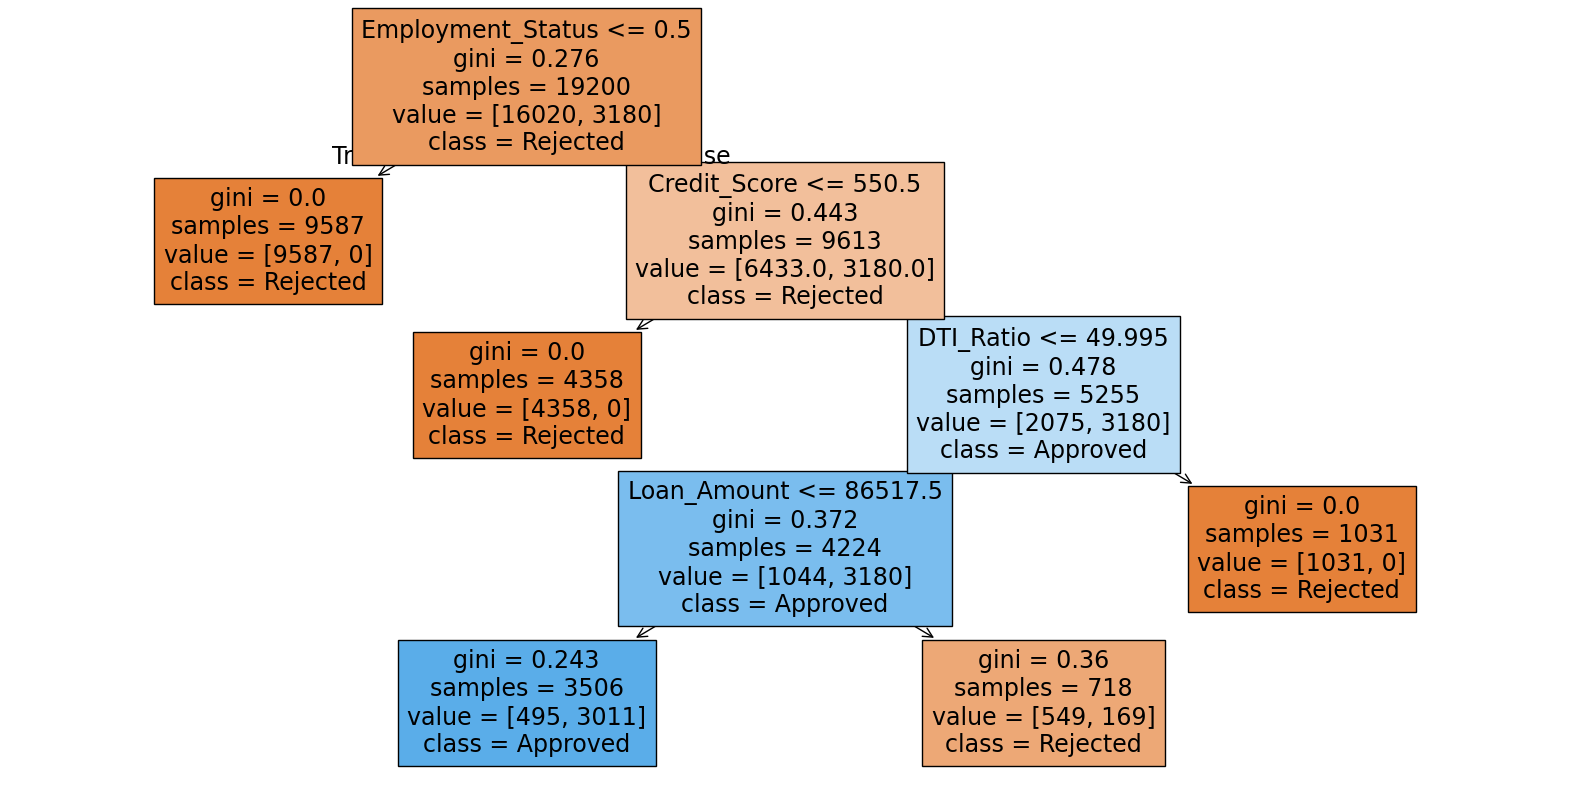

In [21]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True
)
plt.show()

The decision tree model achieved an accuracy of 96%, which indicates strong overall performance.

From the confusion matrix, 3905 applications were correctly classified as rejected, while 706 were correctly classified as approved. However, 142 applications were wrongly classified as approved when they should have been rejected, and 47 applications were wrongly classified as rejected when they should have been approved.

According to the classification report, the model performs very well for rejected applications (Class 0), with a precision of 0.99 and a recall of 0.96. This means the model is highly reliable when predicting rejections and is able to identify most rejected cases correctly.

For approved applications (Class 1), the precision is 0.83 and the recall is 0.94. This means the model identifies most approved cases successfully, although some of its approval predictions are incorrect.

# Feature Importance

             Feature  Importance
1       Credit_Score    0.415625
4  Employment_Status    0.250247
3          DTI_Ratio    0.223773
2        Loan_Amount    0.110355
0             Income    0.000000


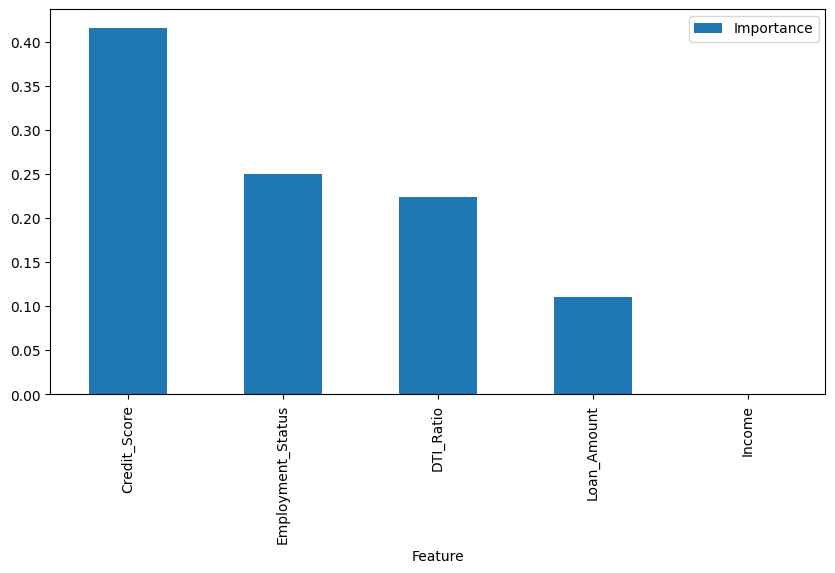

In [22]:
importances = tree_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

# Plot
feature_importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)
plt.show()

Feature Importance Analysis:

The most important feature in the model is Credit Score, contributing approximately 41% to the model's decisions. This indicates that creditworthiness is the strongest factor in determining loan approval.

Employment Status and DTI Ratio are also significant, showing that financial stability and existing debt levels play a key role in the decision-making process.

Loan Amount has a smaller influence, suggesting it is less critical compared to other financial indicators.

Interestingly, Income has zero importance, meaning the model did not use it for any decision splits. This may indicate that Income is either redundant with other features such as DTI Ratio or does not provide additional predictive value.

# Random Forest Model

In [23]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9983333333333333


In [ ]:
rf_model = RandomForestClassifier(random_state=42)

scores = cross_val_score(rf_model, X, y, cv=5)

print(scores)
print("Mean CV accuracy:", scores.mean())

# Save trained models

In [ ]:
joblib.dump(tree_model, "decision_tree_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

# Cross-Validation

The Random Forest model achieved an accuracy of approximately 99.7% based on cross-validation, confirming that the model generalizes well and is not overfitting significantly.

The high performance suggests that the dataset contains strong and clear patterns, particularly in features such as Credit Score and DTI Ratio, which are highly predictive of loan approval outcomes.

While the results are excellent, such high accuracy may not always generalize to real-world data, which is typically more complex and noisy.

# Conclusion

The Decision Tree model achieved an accuracy of 96%, providing a strong baseline for loan approval prediction.

The Random Forest model significantly improved performance, achieving approximately 99.7% accuracy based on cross-validation, indicating strong generalisation.

Feature importance analysis showed that Credit Score, Employment Status, and DTI Ratio were the most influential factors in predicting loan approval.

The results suggest that the dataset contains strong predictive patterns, although real-world data may be more complex and less predictable.

Future improvements could include hyperparameter tuning and testing additional models.